In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_excel("../../datasets/regression_dataset.xlsx")

dataset.head(5)

,Age,Experience,Salary
0,22,0.0,360000
1,25,2.0,520000
2,28,5.0,780000
3,30,7.0,950000
4,33,10.0,1200000


In [2]:
dataset.shape

(10, 3)

In [3]:
dataset.isnull().sum()

Age            0
Experience     1
Salary         0
dtype: int64

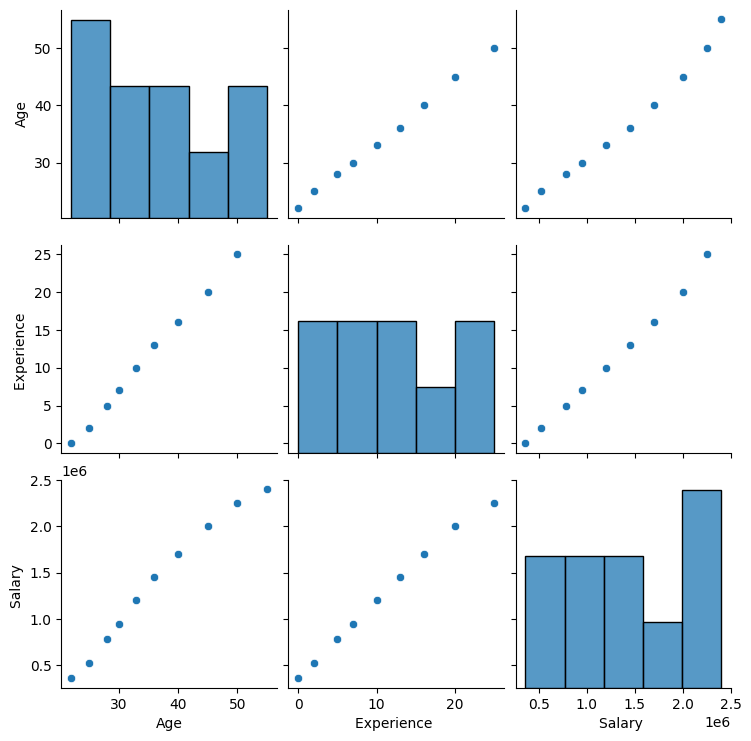

In [4]:
sns.pairplot(data=dataset)
plt.show()

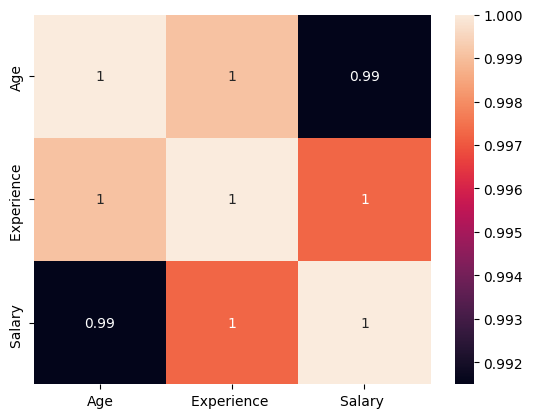

In [5]:
sns.heatmap(data=dataset.corr(), annot=True)
plt.show()

In [6]:
dataset = dataset.dropna() 

In [7]:
x = dataset.iloc[:,: -1]
x

,Age,Experience
0,22,0.0
1,25,2.0
2,28,5.0
3,30,7.0
4,33,10.0
5,36,13.0
6,40,16.0
7,45,20.0
8,50,25.0


In [8]:
y = dataset[dataset.columns[-1]]

In [9]:
dataset.shape

(9, 3)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
lr.score(x_test, y_test)*100

99.09115868521889

In [16]:
lr.coef_

array([-57633.05322129, 140504.20168067])

In [17]:
lr.intercept_

np.float64(1683711.4845938333)

In [18]:
x.columns

Index(['Age', 'Experience '], dtype='str')

In [19]:
lr.predict(x_test)

array([1900308.1232493 ,  523893.55742297])